In [1]:
import os
from pathlib import Path

case_dir = Path(r"C:\Users\XZBbb\Desktop\高速车流量计数器\课件\mnist官方数据集案例改写")
os.chdir(case_dir)
print("当前工作目录:", Path.cwd())

当前工作目录: C:\Users\XZBbb\Desktop\高速车流量计数器\课件\mnist官方数据集案例改写


In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

print("torch version:", torch.__version__)

torch version: 2.11.0+cu128


In [3]:
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

print("训练集数量:", len(training_data))
print("测试集数量:", len(test_data))

训练集数量: 60000
测试集数量: 10000


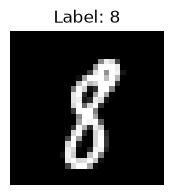

In [4]:
classes = [str(i) for i in range(10)]

img, label = training_data[300]
plt.figure(figsize=(2, 2))
plt.title(f"Label: {classes[label]}")
plt.axis("off")
plt.imshow(img.squeeze(), cmap="gray")
plt.show()

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


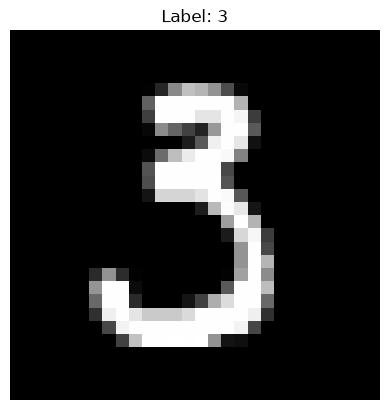

In [5]:
batch_size = 64

train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

img = train_features[0].squeeze()
label = train_labels[0].item()
plt.imshow(img, cmap="gray")
plt.title(f"Label: {classes[label]}")
plt.axis("off")
plt.show()

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [7]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [8]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [9]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss_value = loss.item()
            current = (batch + 1) * len(X)
            print(f"loss: {loss_value:>7f}  [{current:>5d}/{size:>5d}]")


def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100 * correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [10]:
epochs = 10
for t in range(epochs):
    print(f"Epoch {t + 1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.306110  [   64/60000]
loss: 2.300677  [ 6464/60000]
loss: 2.295574  [12864/60000]
loss: 2.280548  [19264/60000]
loss: 2.283721  [25664/60000]
loss: 2.270701  [32064/60000]
loss: 2.280212  [38464/60000]
loss: 2.269727  [44864/60000]
loss: 2.264131  [51264/60000]
loss: 2.252906  [57664/60000]
Test Error: 
 Accuracy: 34.8%, Avg loss: 2.254324 

Epoch 2
-------------------------------
loss: 2.253942  [   64/60000]
loss: 2.246074  [ 6464/60000]
loss: 2.244837  [12864/60000]
loss: 2.235195  [19264/60000]
loss: 2.228079  [25664/60000]
loss: 2.240335  [32064/60000]
loss: 2.201777  [38464/60000]
loss: 2.211011  [44864/60000]
loss: 2.199776  [51264/60000]
loss: 2.184550  [57664/60000]
Test Error: 
 Accuracy: 52.1%, Avg loss: 2.185911 

Epoch 3
-------------------------------
loss: 2.193846  [   64/60000]
loss: 2.185086  [ 6464/60000]
loss: 2.174426  [12864/60000]
loss: 2.159849  [19264/60000]
loss: 2.146574  [25664/60000]
loss: 2.134454  [32064/600

In [11]:
model_path = Path("model_result/mnist_model.pth")
model_path.parent.mkdir(parents=True, exist_ok=True)

torch.save(model.state_dict(), model_path)
print(f"Saved PyTorch Model State to {model_path}")

Saved PyTorch Model State to model_result\mnist_model.pth


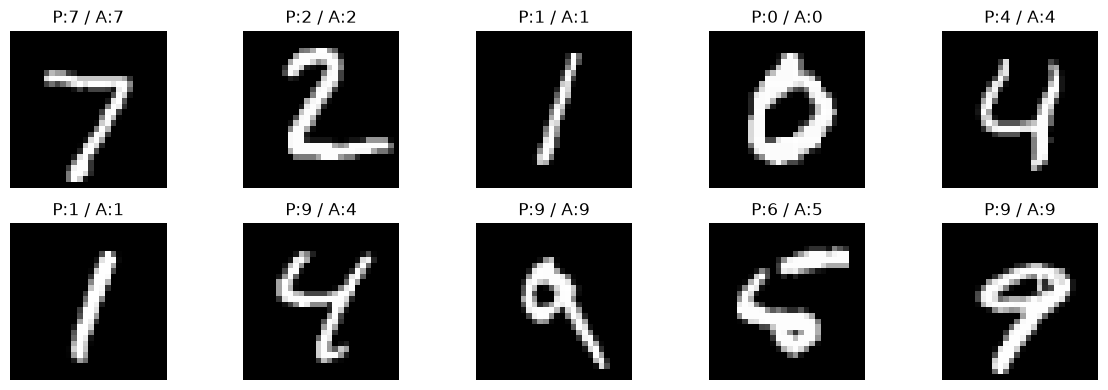

In [13]:
loaded_model = NeuralNetwork().to(device)
loaded_model.load_state_dict(torch.load(model_path, weights_only=True, map_location=device))
loaded_model.eval()

plt.figure(figsize=(12, 4))

with torch.no_grad():
    for i in range(10):
        x, y = test_data[i][0], test_data[i][1]

        pred = loaded_model(x.to(device))
        predicted = classes[pred[0].argmax(0)]
        actual = classes[y]

        plt.subplot(2, 5, i + 1)
        plt.imshow(x.squeeze(), cmap="gray")
        plt.title(f"P:{predicted} / A:{actual}")
        plt.axis("off")

plt.tight_layout()
plt.show()